### Required Assignment 14.1: Decision Trees in Scikit-Learn

**Expected Time = 60 minutes**

**Total Points = 50**

This activity introduces using the `DecisionTreeClassifier` from the `sklearn.tree` module.  You will build some basic models and explore hyperparameters available.  Using the results of the model, you will explore decision boundaries determined by the estimator. 

#### Index 

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)
- [Problem 5](#Problem-5)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split

from sklearn import set_config

set_config("diagram")

### The Data

For this activity, you will again use the `penguins` data from Seaborn.  You will target the two most important features to determining between `Adelie` and `Gentoo`.  

In [2]:
penguins = sns.load_dataset('penguins').dropna()

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [4]:
X = penguins.select_dtypes(['float'])
y = penguins.species

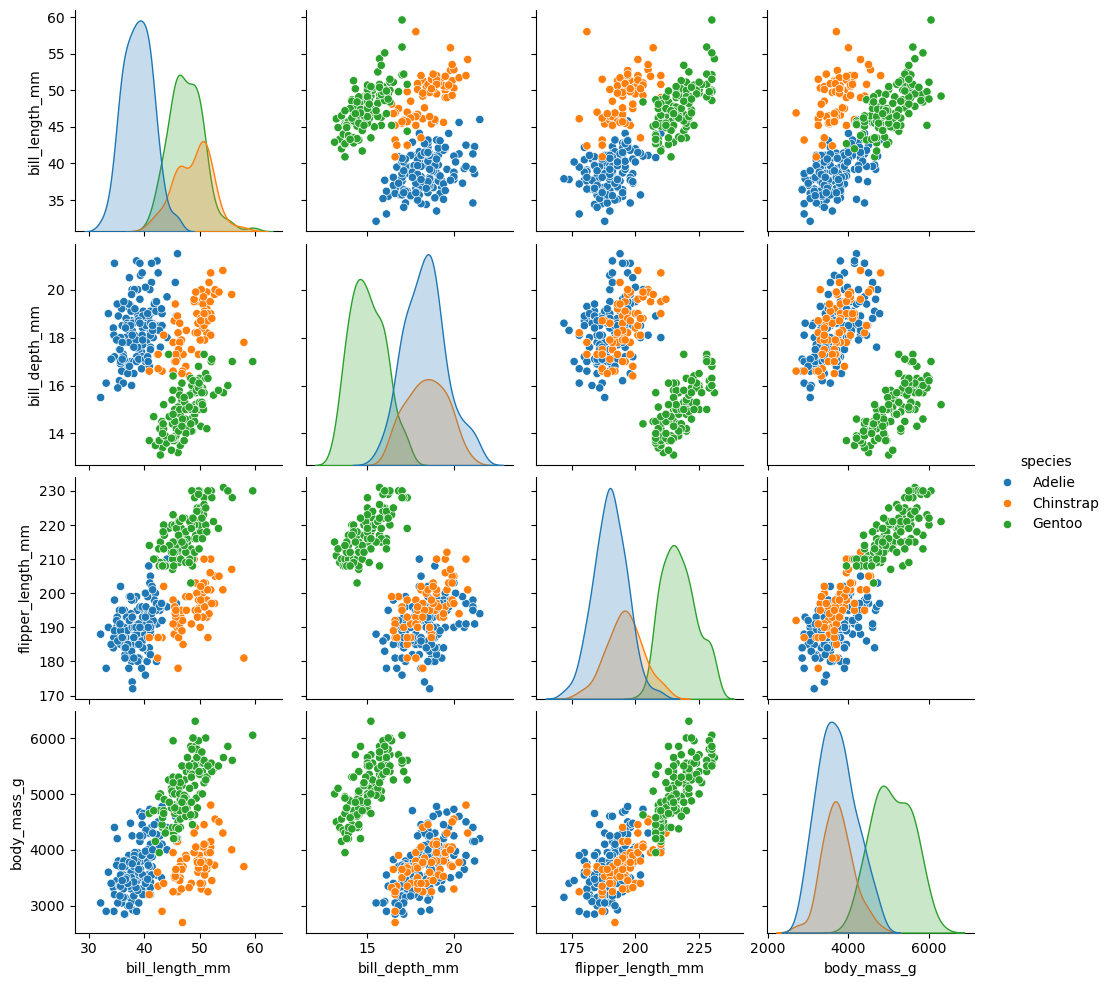

In [5]:
sns.pairplot(data = penguins, hue = 'species')

[Back to top](#-Index)

### Problem 1

#### Fitting a model

To being, build a `DecisionTreeClassifier` with the parameter `max_depth = 1`.  Fit the model on the training data `X` and `y` and assign it to the variable `dtree` below.

**10 Points**



In [6]:
### GRADED

dtree = ''

### BEGIN SOLUTION
dtree = DecisionTreeClassifier(max_depth = 1).fit(X, y)
### END SOLUTION

# Answer check
print(dtree)

DecisionTreeClassifier(max_depth=1)


[Back to top](#-Index)

### Problem 2

#### Examining the Decision

To examine a basic text representation of the fit tree `dtree`, use the `export_text` function and set the argument `feature_names = list(X.columns)`.   Assign the result to `depth_1`.

**10 Points**

In [7]:
### GRADED

depth_1 = ''

### BEGIN SOLUTION
depth_1 = export_text(dtree, feature_names = list(X.columns))
### END SOLUTION

### ANSWER CHECK
print(depth_1)

|--- flipper_length_mm <= 206.50
|   |--- class: Adelie
|--- flipper_length_mm >  206.50
|   |--- class: Gentoo



[Back to top](#-Index)

### Problem 3

#### Two Features

**10 Points**

Now, to make it simpler to plot the boundaries the data is subset to `flipper_length_mm` and `bill_length_mm`. 

Below, instantiate a `DecisionTreeClassifier` instance with `max_depth = 2`. Fit this classifier to the data `X2` and `y`.

Next, use the function `export_text` with arguments `dtree` and `feature_names = list(X2.columns)` and assign your result to `tree2`


<center>
    <img src = 'images/p3.png' />
</center>



In [8]:
### GRADED

X2 = X[['flipper_length_mm', 'bill_length_mm']]
dtree = ''
tree2 = ''

### BEGIN SOLUTION
dtree = DecisionTreeClassifier(max_depth = 2).fit(X2, y)
tree2 = export_text(dtree, feature_names = list(X2.columns))
### END SOLUTION

### ANSWER CHECK
print(tree2)

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_length_mm <= 40.85
|   |   |--- class: Adelie
|   |--- bill_length_mm >  40.85
|   |   |--- class: Gentoo



[Back to top](#-Index)

### Problem 4

#### Evaluating the tree

**10 Points**

Again, the default metric of the classifier is accuracy.  Evaluate the accuracy of the estimator `DecisionTreeClassifier` defined in the previous question and assign as a float to `acc_depth_2` below.  As you see there are a few points misclassified in the image of the decision boundaries.

In [9]:
### GRADED

acc_depth_2 = ''

### BEGIN SOLUTION
acc_depth_2 = DecisionTreeClassifier(max_depth=2).fit(X2, y).score(X2, y)
### END SOLUTION

### ANSWER CHECK
print(acc_depth_2)

0.9519519519519519


[Back to top](#-Index)

### Problem 5

#### A Deeper Tree

**10 Points**

Finally, consider a tree with `max_depth = 3`.  Print the results and and use them to decide a prediction for the following penguin:

| flipper_length_mm | bill_length_mm |
| ----------------- | -------------  |
| 209 | 41.2 |

Assign your results as a string `Adelie`, `Chinstrap`, or `Gentoo` to `prediction` below.

In [ ]:
### GRADED

prediction = ''

### BEGIN SOLUTION
# Create and fit decision tree with max_depth=3
dtree_depth3 = DecisionTreeClassifier(max_depth=3).fit(X2, y)

# Print the tree structure to examine decision rules
tree3_text = export_text(dtree_depth3, feature_names=list(X2.columns))
print(tree3_text)

# Make prediction for flipper_length_mm=209, bill_length_mm=41.2
penguin_features = pd.DataFrame([[209, 41.2]], columns=['flipper_length_mm', 'bill_length_mm'])
prediction = dtree_depth3.predict(penguin_features)[0]
### END SOLUTION

# Answer check
print(prediction)

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.35
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  42.35
|   |   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- bill_length_mm <= 46.05
|   |   |   |--- class: Chinstrap
|   |   |--- bill_length_mm >  46.05
|   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_length_mm <= 40.85
|   |   |--- class: Adelie
|   |--- bill_length_mm >  40.85
|   |   |--- flipper_length_mm <= 212.50
|   |   |   |--- class: Gentoo
|   |   |--- flipper_length_mm >  212.50
|   |   |   |--- class: Gentoo

Gentoo


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
